# **Tropical cyclone detection**

Adrien ACCHIARDI, Xueyun WENG, Mohammed DAHBANI, Nathan SALBEGO
---


Tropical cyclones are extreme meteorological events occuring in tropical zones. The strongs winds and torrential rains that they cause can have serious consequences by causing destruction of human infrastructures. Therefore, it is essentail to study them in order to get a better understanding of their formation and evolution and to minimize potential risks.

A way to detect and study tropical cyclones in the ocean is the observation of SST (sea surface temperature). Indeed, tropical cyclones are formed in warm regions, and the sea surface temperature on the path of the cyclone drops rapidly when the cyclone passes (because of the convection, the rain and the mixing caused by the strongs winds).

We will desribe how to use SST data in order to detect and caracterize tropical cyclones in the gulf of Mexico and around Japan.


# **I-Detecting cyclones using SST averages**


---

In this first part, we will use the SST data to detect tropical cyclones by averaging the SST on the entire study zone.


Let's start by defining useful functions and create the access to the data

In [ ]:
!pip install basemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 942.4/942.4 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.5/30.5 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 23.4 MB/s eta 0:00:00
  Attempting uninstall: pyproj
    Found existing installation: pyproj 3.7.0
    Uninstalling pyproj-3.7.0:
      Successfully uninstalled pyproj-3.7.0
  Attempting uninstall: packaging
    Found existing installation: packaging 24.2
    Uninstalling packaging-24.2:
      Successfully uninstalled packaging-24.2
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0


In [ ]:
import os
os.environ['USE_AUTH_EPHEM'] = '0'

from google.colab import auth
auth.authenticate_user()

In [ ]:
%matplotlib inline
%pylab inline
from mpl_toolkits.basemap import Basemap
import pandas as pd
import warnings
warnings.filterwarnings("ignore") # disable warnings
pylab.rcParams['figure.figsize']=(15,15) # graph size
mpl.rcParams.update({'font.size': 18}) #Pour changer taille des axes

Populating the interactive namespace from numpy and matplotlib


In [ ]:
# function to plot images
def plot_im(lon,lat,im,size_points,var_name):

    # transform to arrays (just in case)
    lon=array(lon)
    lat=array(lat)
    im=array(im)

    if max(lon)-min(lon)<100:
      # Mercator projection (for small zone)
      m=Basemap(projection='merc',llcrnrlat=nanmin(lat),urcrnrlat=nanmax(lat),\
                llcrnrlon=nanmin(lon),urcrnrlon=nanmax(lon),lat_0=(nanmax(lat)+nanmin(lat))*0.5,\
                lon_0=(nanmax(lon)+nanmin(lon))*0.5,resolution='l')
    else:
      # Orthogonal projection (for large zone)
      m=Basemap(projection='ortho',lat_0=0,lon_0=0,resolution='l')
    # you can use other projections (see https://matplotlib.org/basemap/users/mapsetup.html)

    # transform (lon,lat) to (x,y)
    x,y=m(lon,lat)

    # plot
    im=ma.masked_where(isnan(im),im)
    res=m.scatter(x,y,size_points,im,'o',alpha=1,cmap='jet',lw=0)
    m.drawcoastlines()
    m.fillcontinents()
    parallels = linspace(nanmin(lat),nanmax(lat),15)
    meridians = linspace(nanmin(lon),nanmax(lon),15)
    #m.drawparallels(parallels,labels=[1,0,0,1],fontsize=10)
    #m.drawmeridians(meridians,labels=[1,0,0,1],fontsize=10)
    cb=m.colorbar(res,location="right")
    cb.set_label(var_name,fontsize=15)

# function to plot time series
def plot_ts(time,ts,line_type,var_name):

    # plot
    plot_date(time-719177.25,ts,line_type)
    xlabel('Time')
    ylabel(var_name)

We chose to test this first aproach on the coast of Japan.
The following query stored in a dataframe called "japon" the average SST of the whole area grouping by time, year and month

In [ ]:
%%bigquery japon --project alert-ground-261008
SELECT time, year, month, AVG(sst) AS mean_sst
FROM `bdo2020.bdo2020.1998_2015_withtimes`
WHERE lat>20 AND lat<40 AND lon>120  AND lon<145
GROUP BY time, year, month
ORDER BY time, year, month

Query is running:   0%|          |

Downloading:   0%|          |

Then we plot the SST difference between the D day and the D-1 day

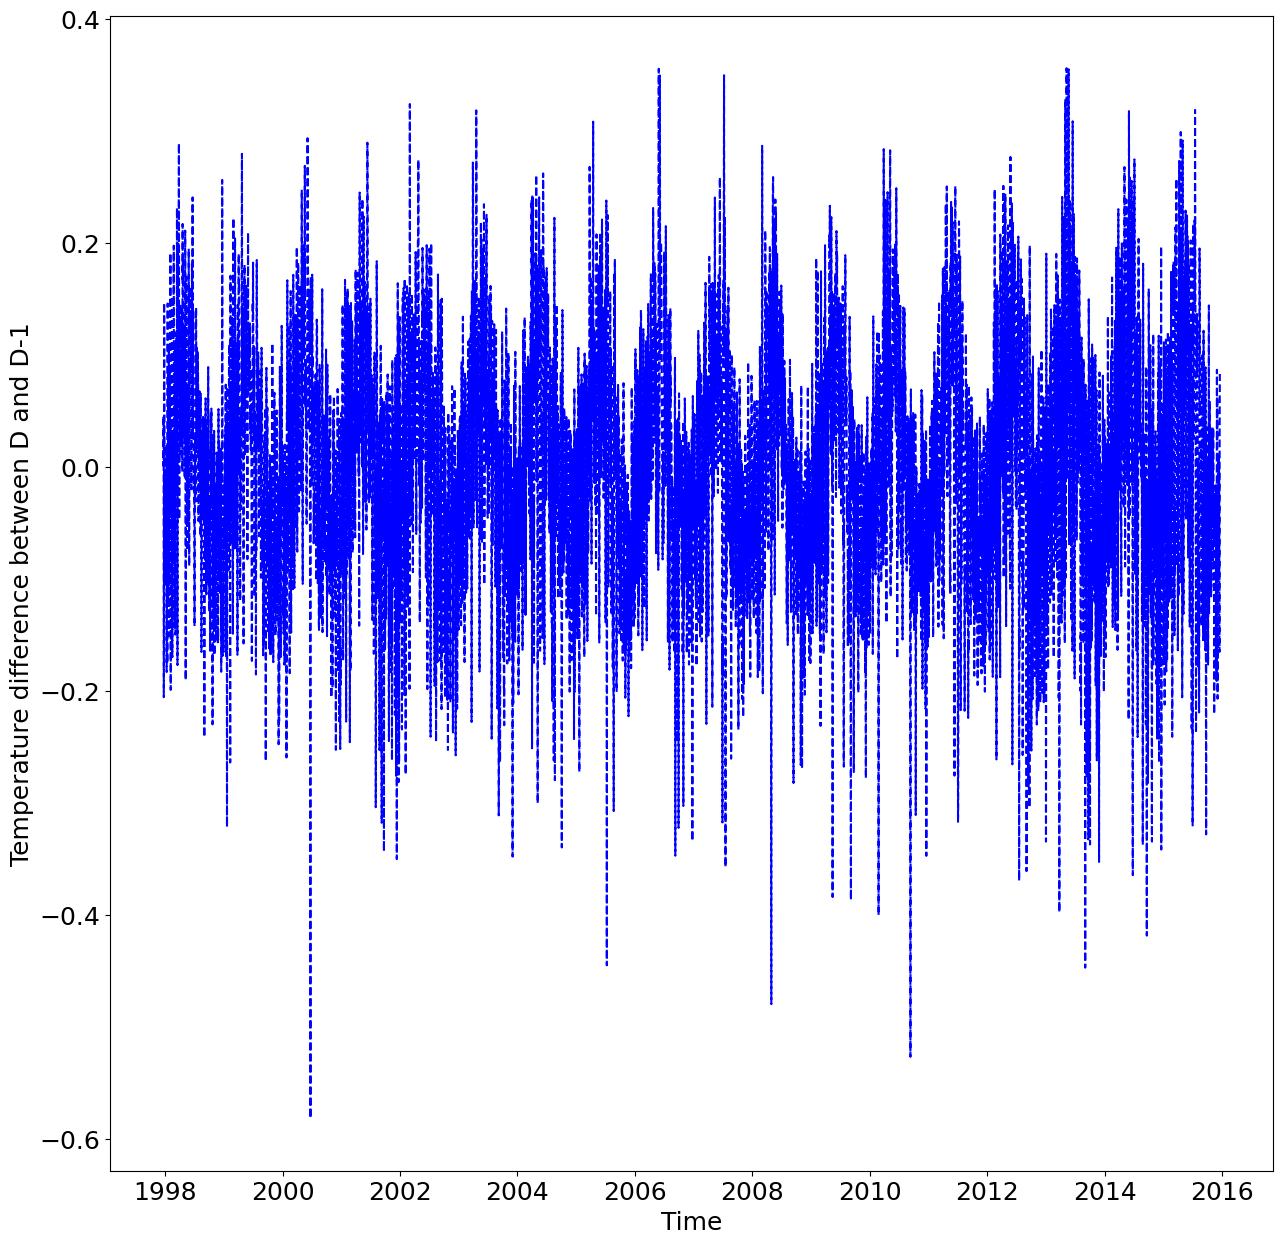

In [ ]:
temperature_diff = japon.mean_sst[1:].values-japon.mean_sst[:-1].values
plot_ts(japon.time[1:],temperature_diff,"--b", "Temperature difference between D and D-1")

According to the previous graph, if the SST difference is lower than -0.25 then it's likely due to a hurricane. Therefore, we'll detect the hurricane based on the threshold of -0.25 and using this way to count the number of hurricanes monthly from the dataframe cyclone_df

Text(0.5, 1.0, 'Number of cyclones per year between 1998 and 2015 in Japan')

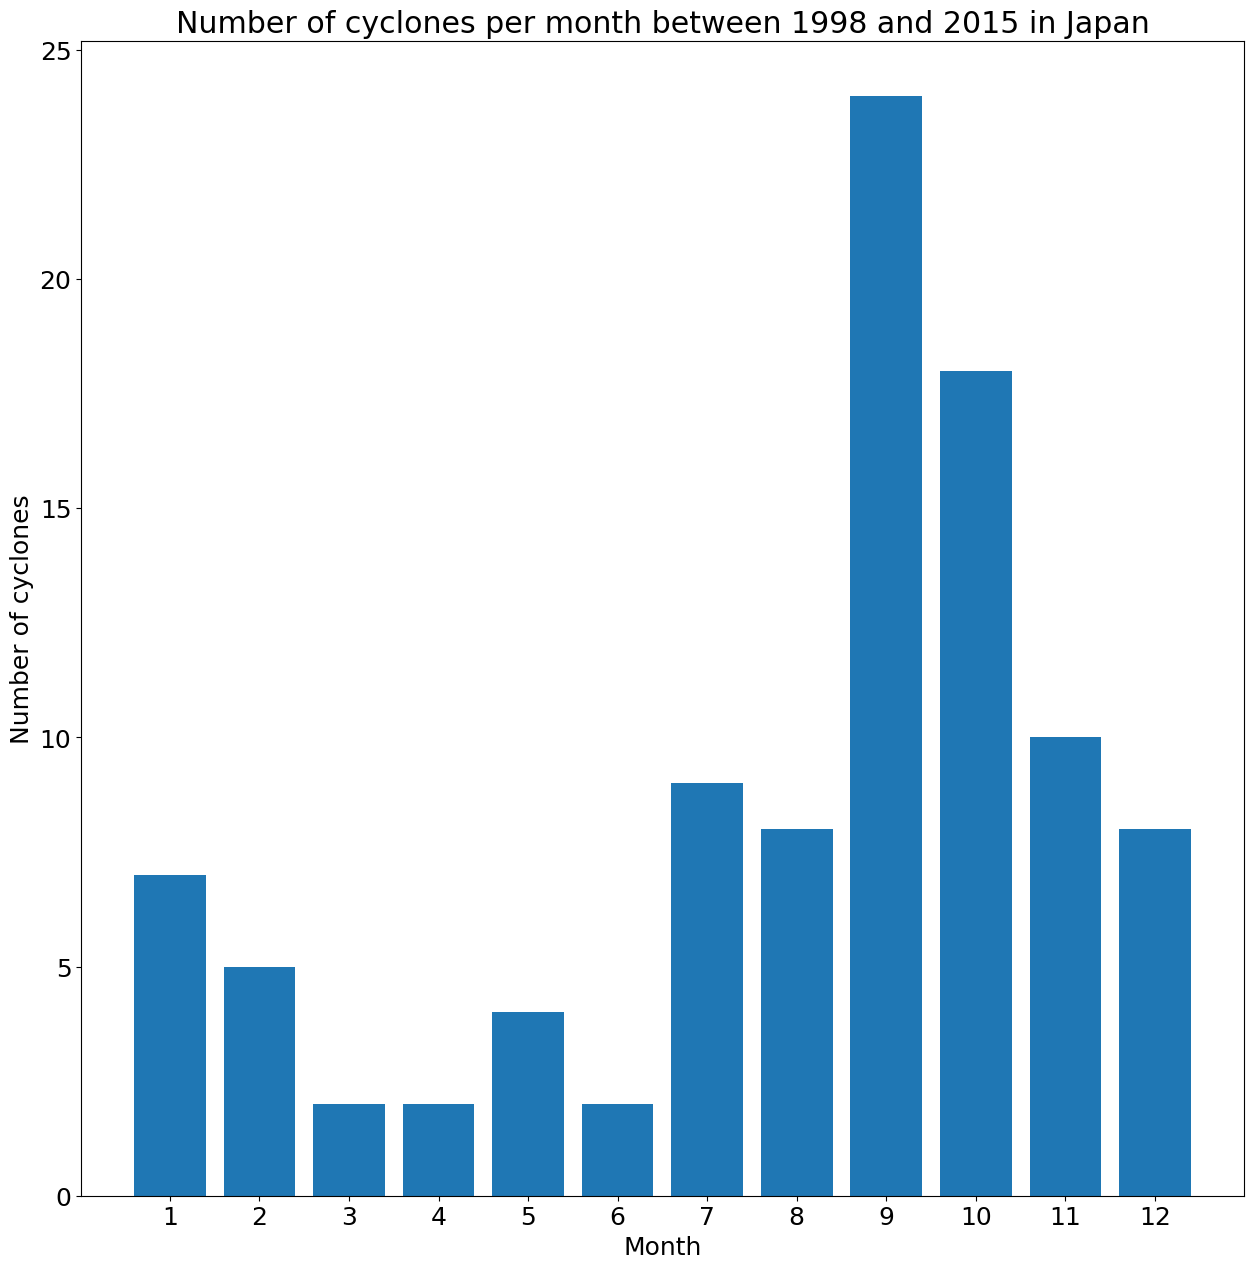

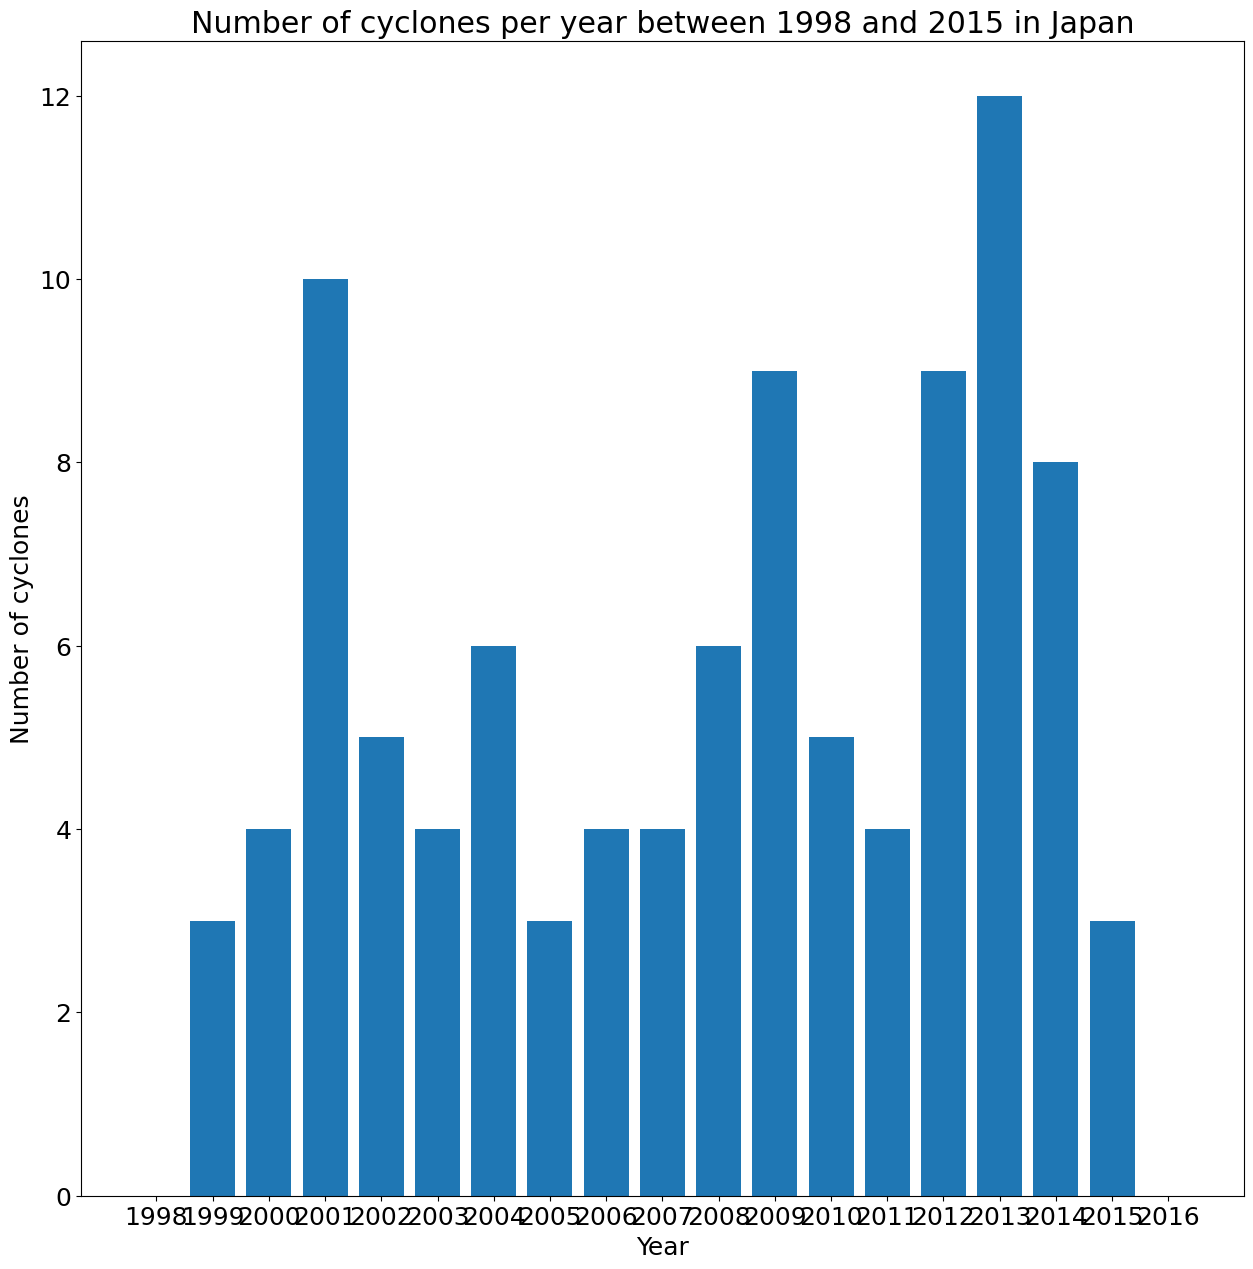

In [ ]:
seuil = -0.25
binary_array = (temperature_diff < seuil).astype(int)
japon["cyclone"] = np.insert(binary_array, 0, 0)
cyclone_df = pd.DataFrame(japon.groupby('month')['cyclone'].apply(lambda x: (x == 1).sum())).reset_index()

plt.bar(cyclone_df['month'], cyclone_df['cyclone'])
plt.xlabel("Month")
plt.xticks(cyclone_df['month'])
plt.ylabel("Number of cyclones")
plt.title("Number of cyclones per month between 1998 and 2015 in Japan")


cyclone_df = pd.DataFrame(japon.groupby('year')['cyclone'].apply(lambda x: (x == 1).sum())).reset_index()

figure()
plt.bar(cyclone_df['year'], cyclone_df['cyclone'])
plt.xlabel("Year")
plt.xticks(cyclone_df['year'])
plt.ylabel("Number of cyclones")
plt.title("Number of cyclones per year between 1998 and 2015 in Japan")

Cyclones typically occur during the summer months, so using the average SST is not an efficient approach. Therefore, we decided to pursue a different method.

# **II-Point by point detection**

---

Since the result obtained in the first section aren't satisfying, we now take a different approach. Rather than averaging the temperature over the entire zone, we calculate the number of cyclones on each cell for a given periode based on the temperature difference between consecutive days on every cell of the data grid using a threshold (2 degree drop from one day to the next on the cell).

## **1. The gulf of Mexico (2005, June, July, August, September)**

In [ ]:
%%bigquery data_mex --project alert-ground-261008
WITH temperature_diff AS (
  SELECT
    lon,
    lat,
    day,
    month,
    year,
    sst,
    CASE
      WHEN LAG(lon) OVER (ORDER BY lon, lat, time) = lon
           AND LAG(lat) OVER (ORDER BY lon, lat, time) = lat THEN
        sst - LAG(sst) OVER (ORDER BY lon, lat, time)
      ELSE
        NULL
    END AS temperature_difference
  FROM
    bdo2020.bdo2020.1998_2015_withtimes
  WHERE
    lon > 260 AND lon < 280
    AND lat > 15 AND lat < 35 AND month IN (6,7,8,9) AND year=2005
  ORDER BY
    lon, lat, time
),
cyclone_days AS (
  SELECT
    lon,
    lat,
    day,
    month,
    year,
    temperature_difference,
    CASE
      WHEN temperature_difference <= -2 THEN 1
      ELSE 0
    END AS is_cyclone_day
  FROM
    temperature_diff
)
SELECT
  lon,
  lat,
  SUM(is_cyclone_day) AS cyclone_count
FROM
  cyclone_days
GROUP BY
  lon, lat
ORDER BY
  lon, lat

Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
data_mex

,lon,lat,cyclone_count
0,260.125,15.125,0
1,260.125,15.375,0
2,260.125,15.625,0
3,260.125,15.875,0
4,260.125,16.125,0
...,...,...,...
2311,279.875,30.625,0
2312,279.875,30.875,0
2313,279.875,31.125,0
2314,279.875,31.375,0


Text(0.5, 1.0, 'Number of Tropical cyclones in the gulf of Mexico in summer 2005 , size=204')

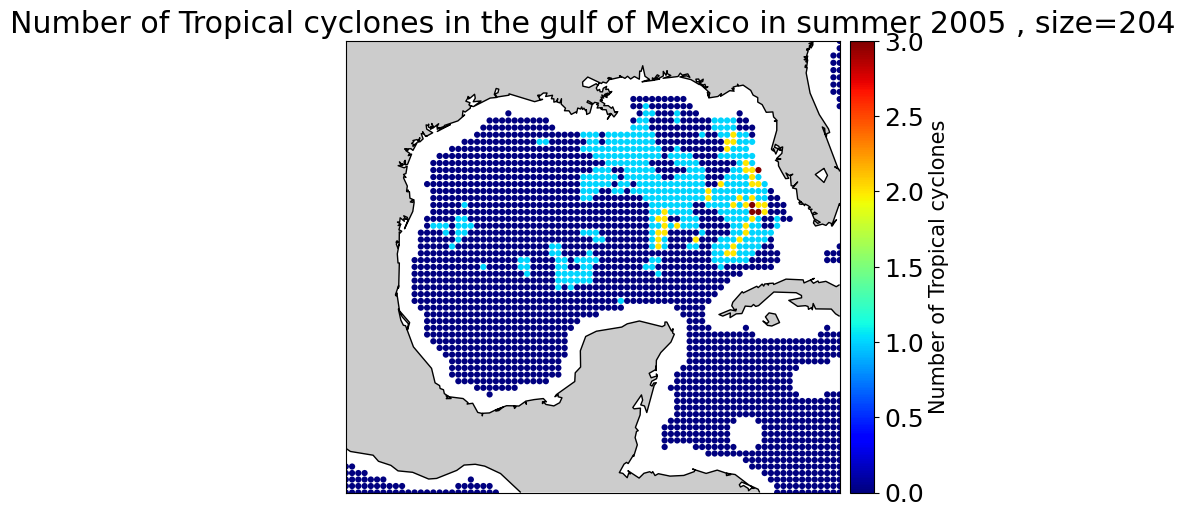

In [ ]:
figure()
subplot(1,2,1)
plot_im(data_mex.lon, data_mex.lat, data_mex.cyclone_count, 20, 'Number of Tropical cyclones')
title('Number of Tropical cyclones in the gulf of Mexico in summer 2005 , size=204')

By comparing our results to the map below, extracted from the Historical Hurricane Tracks, the outcome appears to be highly consistent. (Summer 2005)
![Hurricanes in the guld of Mexica in summer 2005.](https://drive.google.com/uc?id=1zRi49EbD9QAC7IefG3PB85GO_cgkPY_D)

## **2.The coast of Japan**

In [ ]:
%%bigquery data_jap --project alert-ground-261008
WITH temperature_diff AS (
  SELECT
    lon,
    lat,
    day,
    sst,
    CASE
      WHEN LAG(lon) OVER (ORDER BY lon, lat, time) = lon
           AND LAG(lat) OVER (ORDER BY lon, lat, time) = lat THEN
        sst - LAG(sst) OVER (ORDER BY lon, lat, time)
      ELSE
        NULL
    END AS temperature_difference
  FROM
    bdo2020.bdo2020.1998_2015_withtimes
  WHERE
    lat>0 AND lat<40 AND lon>120  AND lon<160 AND month>5 AND month<10 AND year=2015
  ORDER BY
    lon, lat, time
),
cyclone_days AS (
  SELECT
    lon,
    lat,
    day,
    CASE
      WHEN temperature_difference <= -2 THEN 1
      ELSE 0
    END AS is_cyclone_day
  FROM
    temperature_diff
)
SELECT
  lon,
  lat,
  SUM(is_cyclone_day) AS cyclone_count
FROM
  cyclone_days
GROUP BY
  lon, lat
ORDER BY
  lon, lat

Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
data_jap

,lon,lat,cyclone_count
0,120.125,1.875,0
1,120.125,2.125,0
2,120.125,2.375,0
3,120.125,2.625,0
4,120.125,2.875,0
...,...,...,...
21153,159.875,38.875,1
21154,159.875,39.125,1
21155,159.875,39.375,1
21156,159.875,39.625,1


Text(0.5, 1.0, 'Number of Tropical cyclones in the coast of Japan in summer 2015 , size=204')

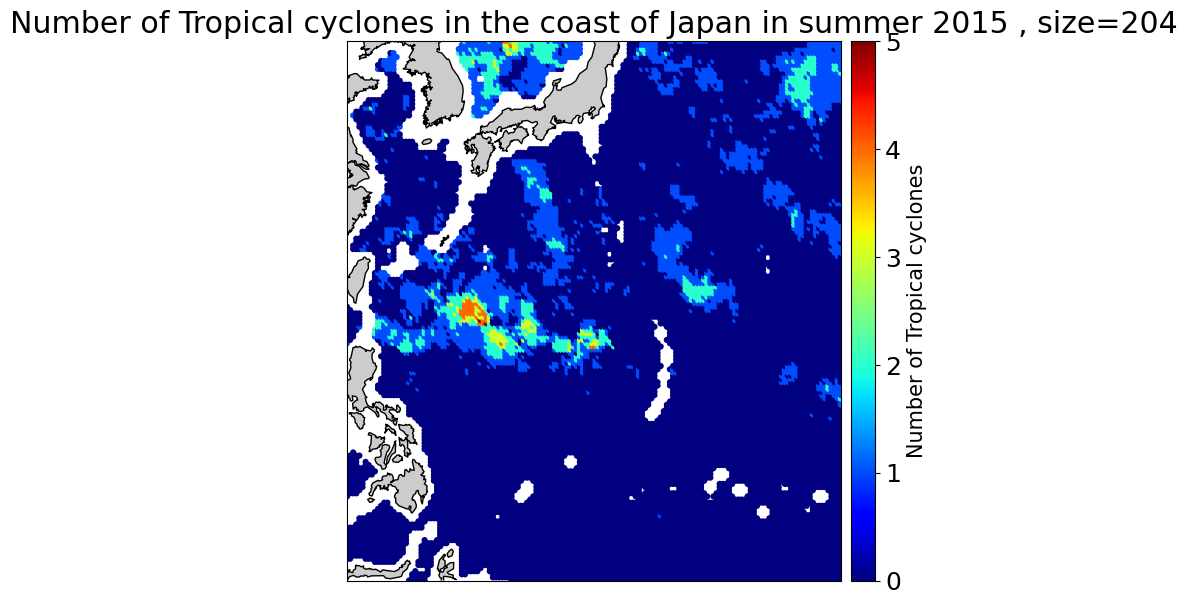

In [ ]:
figure()
subplot(1,2,1)
plot_im(data_jap.lon, data_jap.lat, data_jap.cyclone_count, 20, 'Number of Tropical cyclones')
title('Number of Tropical cyclones in the coast of Japan in summer 2015 , size=204')

Also, by comparing our results to the map below, extracted from the Historical Hurricane Tracks, the outcome appears to be highly consistent. (Summer 2015)
![Hurricanes in the coast of japan in summer 2015.](https://drive.google.com/uc?id=1U7iHdOBRHSClxmsyQRuiw9JrTAnLiOBo)


##  **3.Application 1: SST difference map during hurricane Katrina (August 2005)**

For example, we can look at the SST difference map during hurricane Katrina (August 2005)

In [ ]:
%%bigquery data_mx --project alert-ground-261008
SELECT
    time, sst-LAG(sst) OVER (ORDER BY lon, lat, time) AS sst_diff, lon, lat, month, year, day
  FROM `bdo2020.bdo2020.1998_2015_withtimes`
  WHERE lon > 260 AND lon < 280
    AND lat > 15 AND lat < 35

Query is running:   0%|          |

Downloading:   0%|          |

Text(0.5, 1.0, 'SST difference during hurricane Katrina (30th August) , size=204')

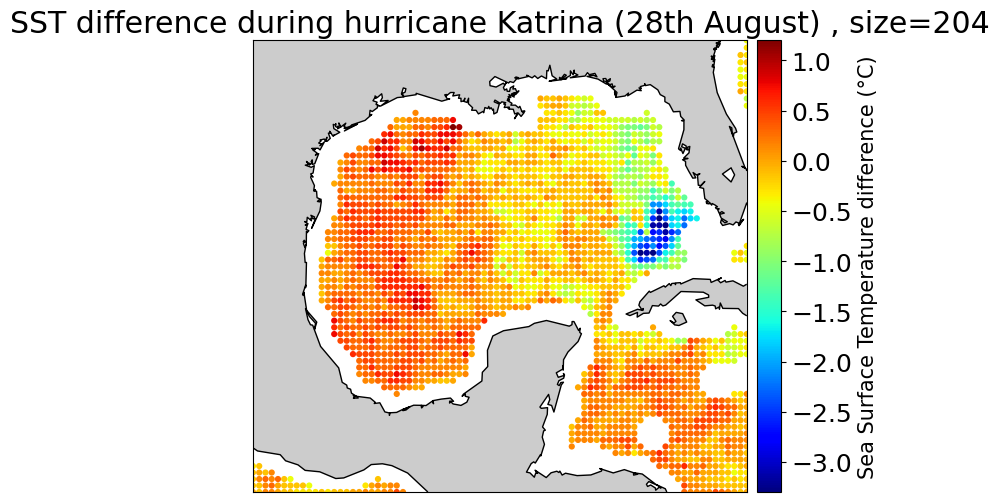

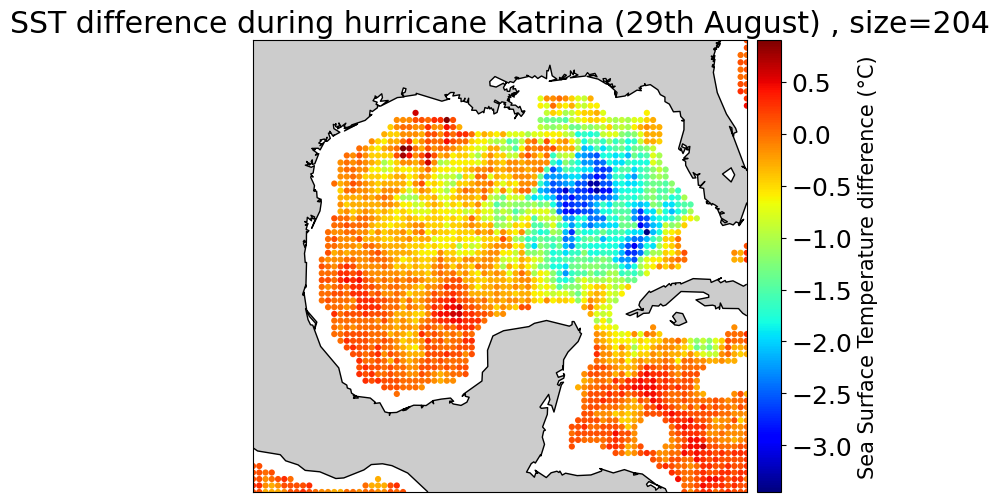

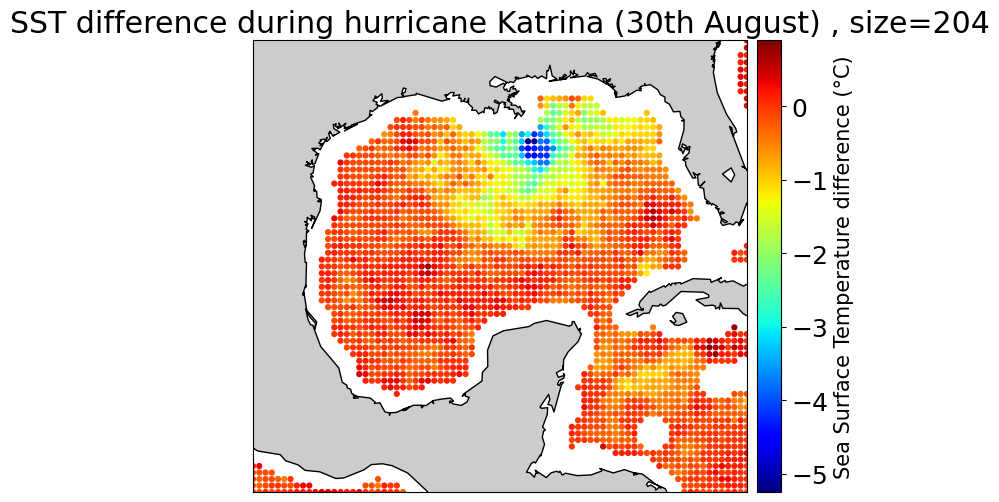

In [ ]:
data_mx1=data_mx[(data_mx['year']==2005) & (data_mx['month']==8) & (data_mx['day']==28)]
data_mx2=data_mx[(data_mx['year']==2005) & (data_mx['month']==8) & (data_mx['day']==29)]
data_mx3=data_mx[(data_mx['year']==2005) & (data_mx['month']==8) & (data_mx['day']==30)]
figure()
subplot(1,2,1)
plot_im(data_mx1.lon, data_mx1.lat, data_mx1.sst_diff, 20, 'Sea Surface Temperature difference (°C)')
title('SST difference during hurricane Katrina (28th August) , size=204')
figure()
subplot(1,2,1)
plot_im(data_mx2.lon, data_mx2.lat, data_mx2.sst_diff, 20, 'Sea Surface Temperature difference (°C)')
title('SST difference during hurricane Katrina (29th August) , size=204')
figure()
subplot(1,2,1)
plot_im(data_mx3.lon, data_mx3.lat, data_mx3.sst_diff, 20, 'Sea Surface Temperature difference (°C)')
title('SST difference during hurricane Katrina (30th August) , size=204')

As we can observe, the blue pixels indicating the drop in temperature illustrate the progression of Hurricane Katrina.

## **4.Application 2: Number of tropical cyclone per month and per year in the gulf of Mexico**

In [ ]:
%%bigquery data_mex1 --project alert-ground-261008
WITH temperature_diff AS (
  SELECT
    lon,
    lat,
    sst,
    CASE
      WHEN LAG(lon) OVER (ORDER BY lon, lat, time) = lon
           AND LAG(lat) OVER (ORDER BY lon, lat, time) = lat THEN
        sst - LAG(sst) OVER (ORDER BY lon, lat, time)
      ELSE
        NULL
    END AS temperature_difference
  FROM
    bdo2020.bdo2020.1998_2015_withtimes
  WHERE
    lon > 260 AND lon < 280
    AND lat > 20 AND lat < 35
  ORDER BY
    lon, lat, time
),
cyclone_days AS (
  SELECT
    lon,
    lat,
    temperature_difference,
    CASE
      WHEN temperature_difference <= -2 THEN 1
      ELSE 0
    END AS is_cyclone_day
  FROM
    temperature_diff
)
SELECT
  lon,
  lat,
  SUM(is_cyclone_day) AS cyclone_count
FROM
  cyclone_days
GROUP BY
  lon, lat
ORDER BY
  lon, lat

Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
data_mex1

,lon,lat,cyclone_count
0,262.875,22.375,0
1,262.875,22.625,0
2,262.875,22.875,0
3,262.875,23.125,0
4,262.875,23.375,0
...,...,...,...
1797,279.875,30.625,0
1798,279.875,30.875,2
1799,279.875,31.125,3
1800,279.875,31.375,1


Text(0.5, 1.0, 'Number of Tropical cyclones per pixel in the gulf of Mexico(1998- 2015) , size=204')

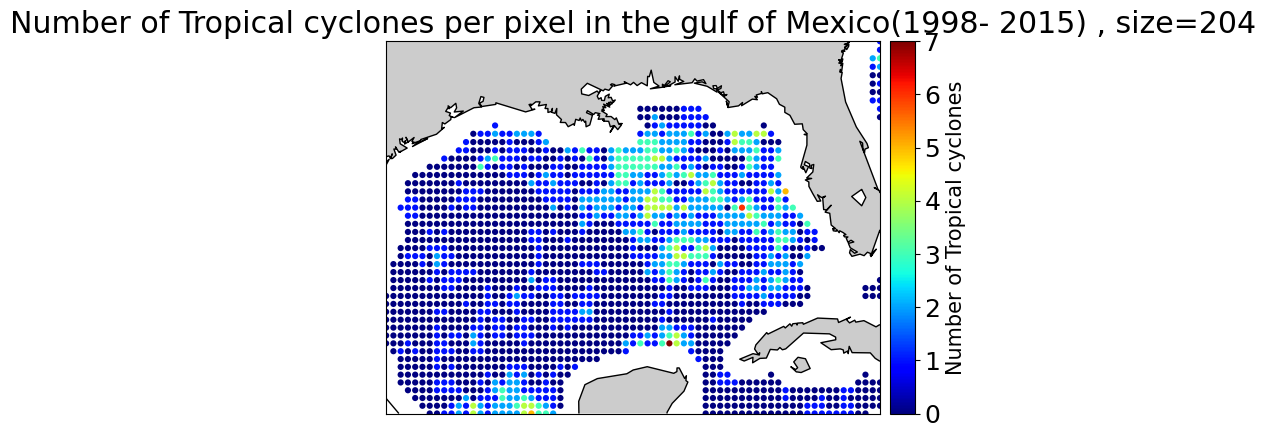

In [ ]:
figure()
plt.subplot(1,2,1)
plot_im(data_mex1.lon, data_mex1.lat, data_mex1.cyclone_count, 20, 'Number of Tropical cyclones')
title('Number of Tropical cyclones per pixel in the gulf of Mexico(1998- 2015) , size=204')

We can extract the date (day/month/year) of tropical cyclones in the following way: if at least on of the cells from the grid signals a cyclone on a given day, then we consider that there is a cyclone that day. We can therefore calculate the number of cyclones per year and month in order to verify the coherence of the result with what we expected

In [ ]:
%%bigquery is_cyclone_day --project alert-ground-261008
WITH temperature_diff AS (
  SELECT
    lon,
    lat,
    day,
    month,
    year,
    sst,
    CASE
      WHEN LAG(lon) OVER (ORDER BY lon, lat, time) = lon
           AND LAG(lat) OVER (ORDER BY lon, lat, time) = lat THEN
        sst - LAG(sst) OVER (ORDER BY lon, lat, time)
      ELSE
        NULL
    END AS temperature_difference
  FROM
    bdo2020.bdo2020.1998_2015_withtimes
  WHERE
    lon > 260 AND lon < 280
    AND lat > 20 AND lat < 35
  ORDER BY
    lon, lat, time
)
  SELECT
    lon,
    lat,
    day,
    month,
    year,
    temperature_difference,
    CASE
      WHEN temperature_difference <= -2.5 THEN 1
      ELSE 0
    END AS is_cyclone_day
  FROM
    temperature_diff

Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
import seaborn as sns

Text(0.5, 1.0, 'Number of cyclones for each year between 1998-2015 in the Gulf of Mexico')

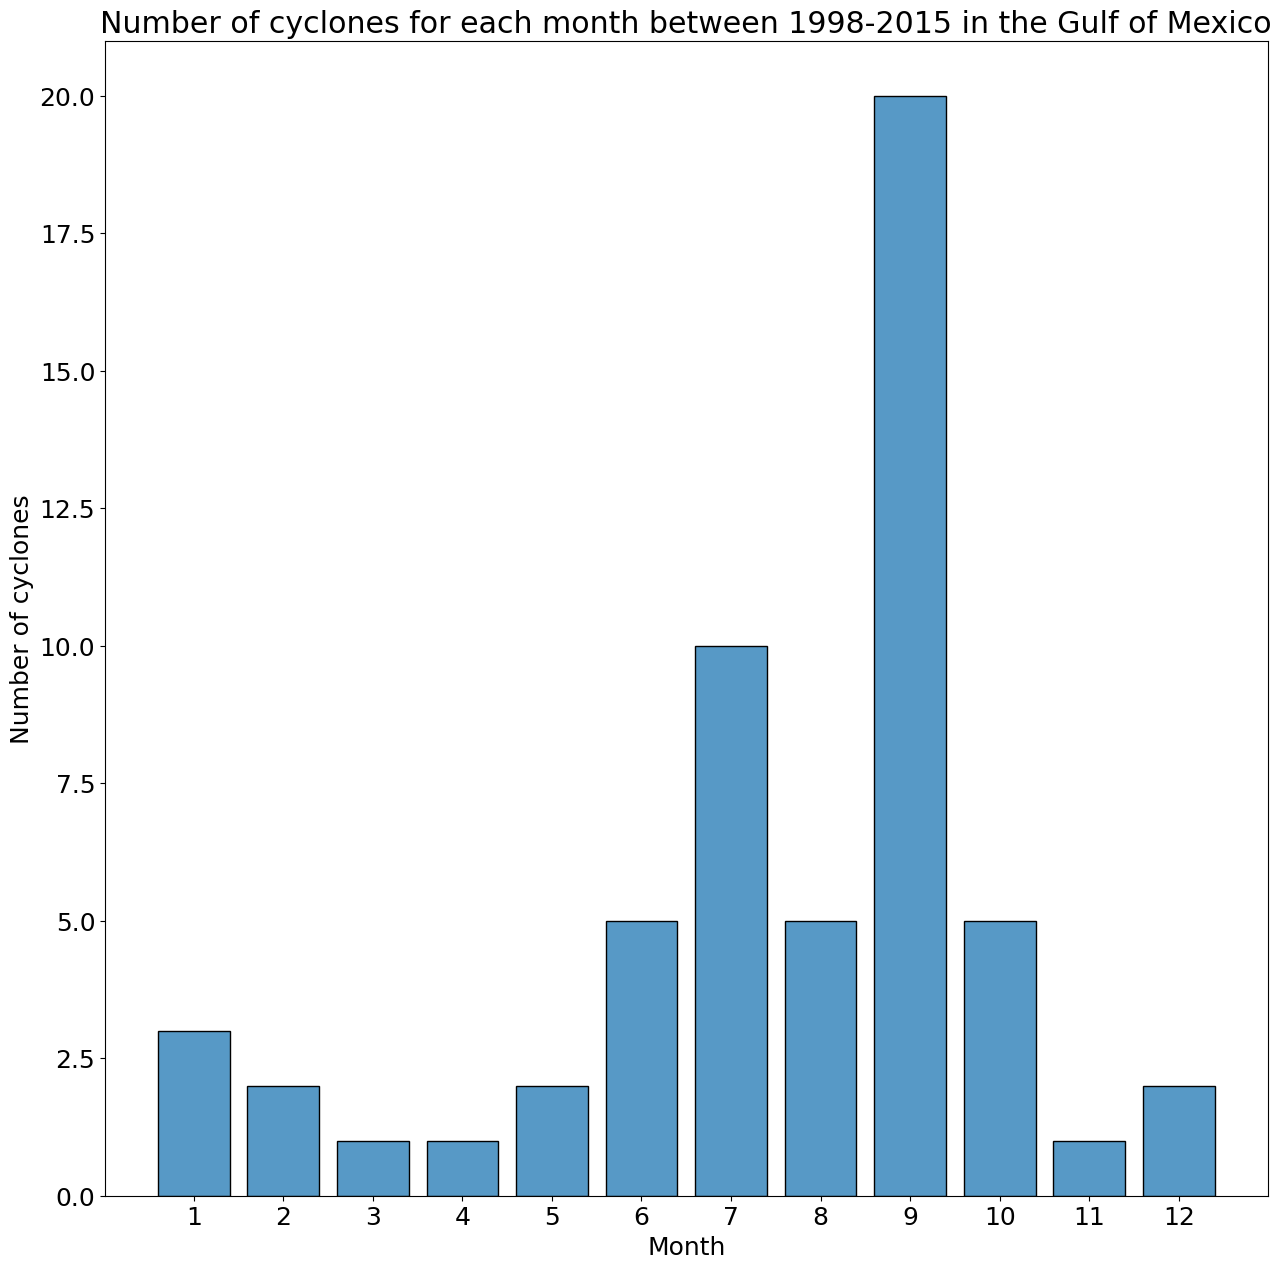

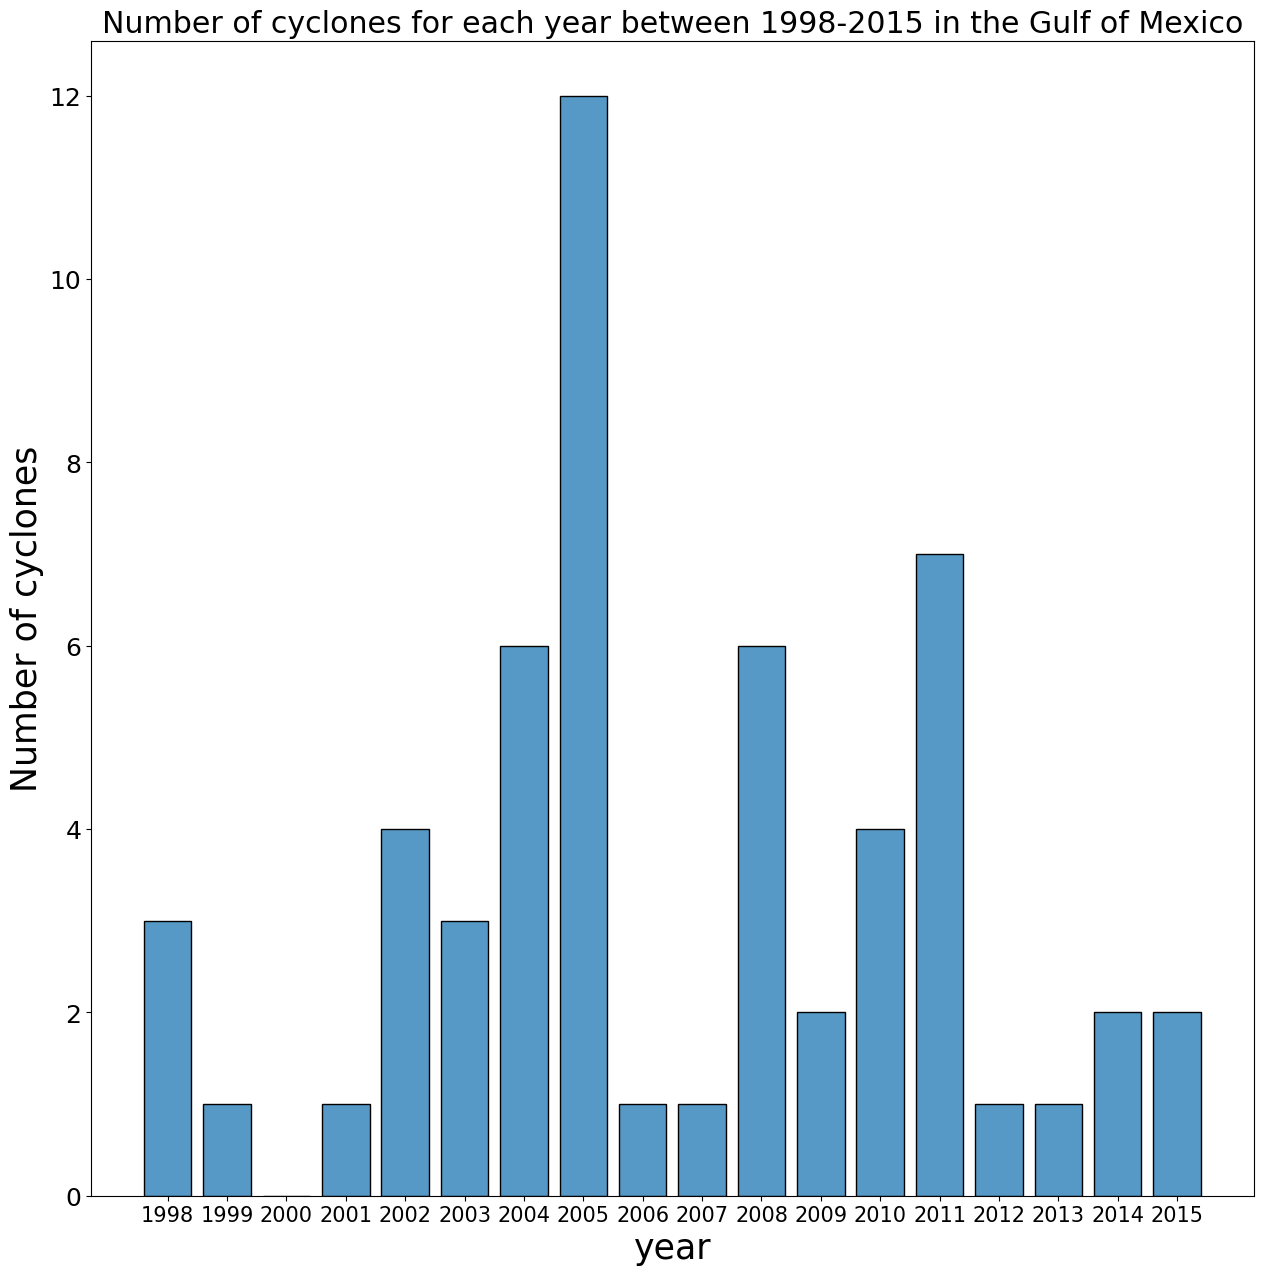

In [ ]:
is_cyclone_day1=is_cyclone_day[(is_cyclone_day['is_cyclone_day']==1)]
is_cyclone_day1=is_cyclone_day1[['day', 'month', 'year', 'is_cyclone_day']]
is_cyclone_day1=is_cyclone_day1.groupby(['year','month', 'day']).mean()

# len(is_cyclone_day1.index.get_level_values('year'))
sns.histplot(is_cyclone_day1.index.get_level_values('month'),shrink=0.8,bins=[i for i in range(1,13)],discrete=True)
ylabel('Number of cyclones')
xlabel('Month')
plt.xticks([i for i in range(1,13)])
title('Number of cyclones for each month between 1998-2015 in the Gulf of Mexico')

figure()
sns.histplot(is_cyclone_day1.index.get_level_values('year'),shrink=0.8,bins=[i for i in range(1998,2016)],discrete=True)
ylabel('Number of cyclones',fontsize=25)
xlabel('year',fontsize=25)
plt.xticks([i for i in range(1998,2016)],fontsize=15)
title('Number of cyclones for each year between 1998-2015 in the Gulf of Mexico')

As expected, cyclones appear very frequently during the end of summer (higher SST), and they are very rare in winter.

We also notice that there are more cyclones during certain years (like 2005 for example).

## **5.Application 3: Number of tropical cyclone per month and per year in the coast of Japan**

In [ ]:
%%bigquery data_jap1 --project alert-ground-261008
WITH temperature_diff AS (
  SELECT
    lon,
    lat,
    day,
    sst,
    CASE
      WHEN LAG(lon) OVER (ORDER BY lon, lat, time) = lon
           AND LAG(lat) OVER (ORDER BY lon, lat, time) = lat THEN
        sst - LAG(sst) OVER (ORDER BY lon, lat, time)
      ELSE
        NULL
    END AS temperature_difference
  FROM
    bdo2020.bdo2020.1998_2015_withtimes
  WHERE
    lat>0 AND lat<40 AND lon>120  AND lon<160
  ORDER BY
    lon, lat, time
),
cyclone_days AS (
  SELECT
    lon,
    lat,
    day,
    CASE
      WHEN temperature_difference <= -2 THEN 1
      ELSE 0
    END AS is_cyclone_day
  FROM
    temperature_diff
)
SELECT
  lon,
  lat,
  SUM(is_cyclone_day) AS cyclone_count
FROM
  cyclone_days
GROUP BY
  lon, lat
ORDER BY
  lon, lat

Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
data_jap1

,lon,lat,cyclone_count
0,120.125,1.875,0
1,120.125,2.125,0
2,120.125,2.375,0
3,120.125,2.625,0
4,120.125,2.875,0
...,...,...,...
21153,159.875,38.875,6
21154,159.875,39.125,3
21155,159.875,39.375,3
21156,159.875,39.625,3


Text(0.5, 1.0, 'Number of Tropical cyclones per pixel in the coast of Japan(1998- 2015) , size=204')

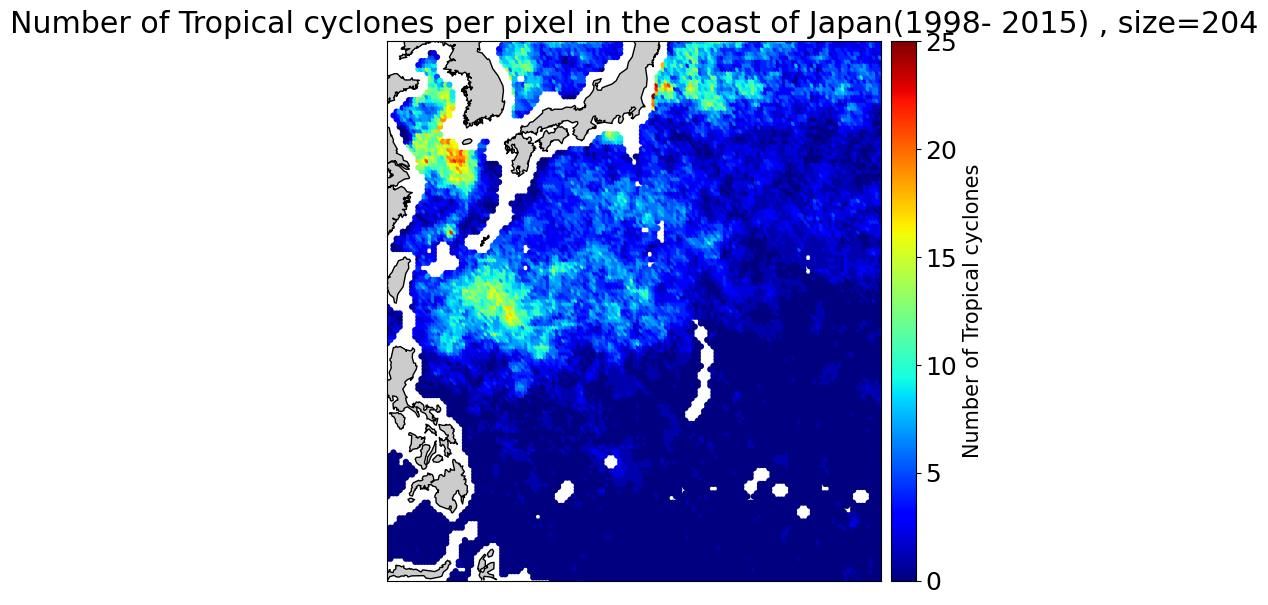

In [ ]:
figure()
plt.subplot(1,2,1)
plot_im(data_jap1.lon, data_jap1.lat, data_jap1.cyclone_count, 20, 'Number of Tropical cyclones')
title('Number of Tropical cyclones per pixel in the coast of Japan(1998- 2015) , size=204')

In [ ]:
%%bigquery is_cyclone_day --project alert-ground-261008
WITH temperature_diff AS (
  SELECT
    lon,
    lat,
    day,
    month,
    year,
    sst,
    CASE
      WHEN LAG(lon) OVER (ORDER BY lon, lat, time) = lon
           AND LAG(lat) OVER (ORDER BY lon, lat, time) = lat THEN
        sst - LAG(sst) OVER (ORDER BY lon, lat, time)
      ELSE
        NULL
    END AS temperature_difference
  FROM
    bdo2020.bdo2020.1998_2015_withtimes
  WHERE
  lat>20 AND lat<40 AND lon>120  AND lon<140

)
  SELECT
    lon,
    lat,
    day,
    month,
    year,
    temperature_difference,
    CASE
      WHEN temperature_difference <= -2.5 THEN 1
      ELSE 0
    END AS is_cyclone_day
  FROM
    temperature_diff

Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
import seaborn as sns

Text(0.5, 1.0, 'Number of cyclones for each year between 1998-2015 in the coast of Japan')

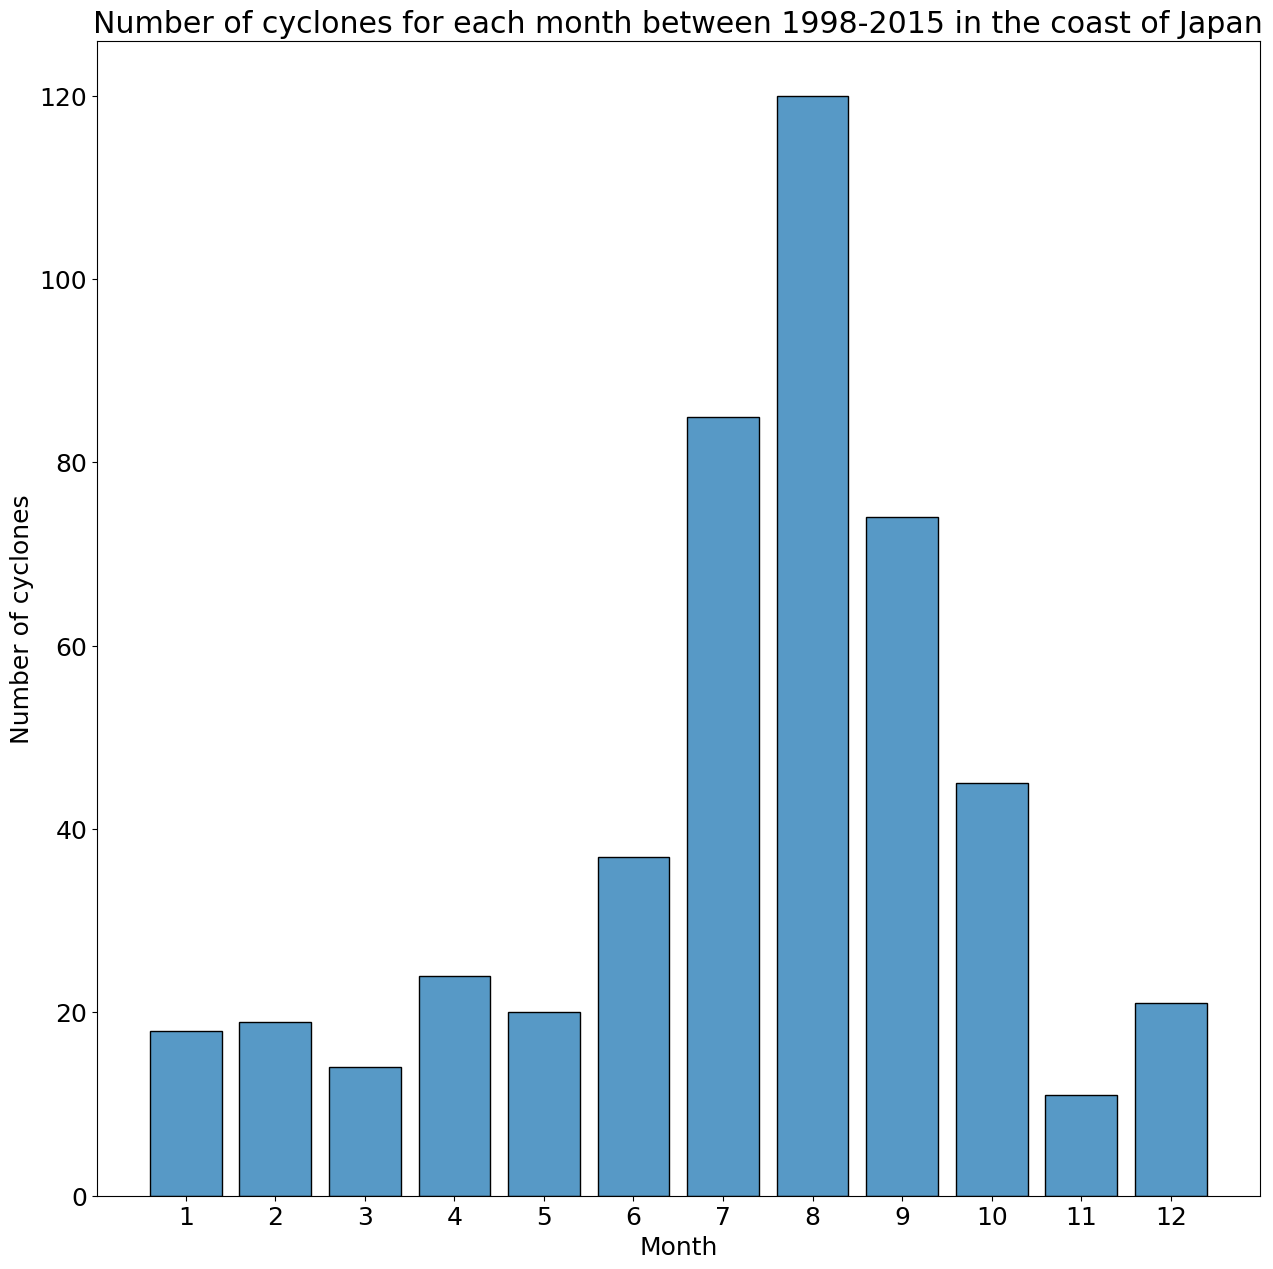

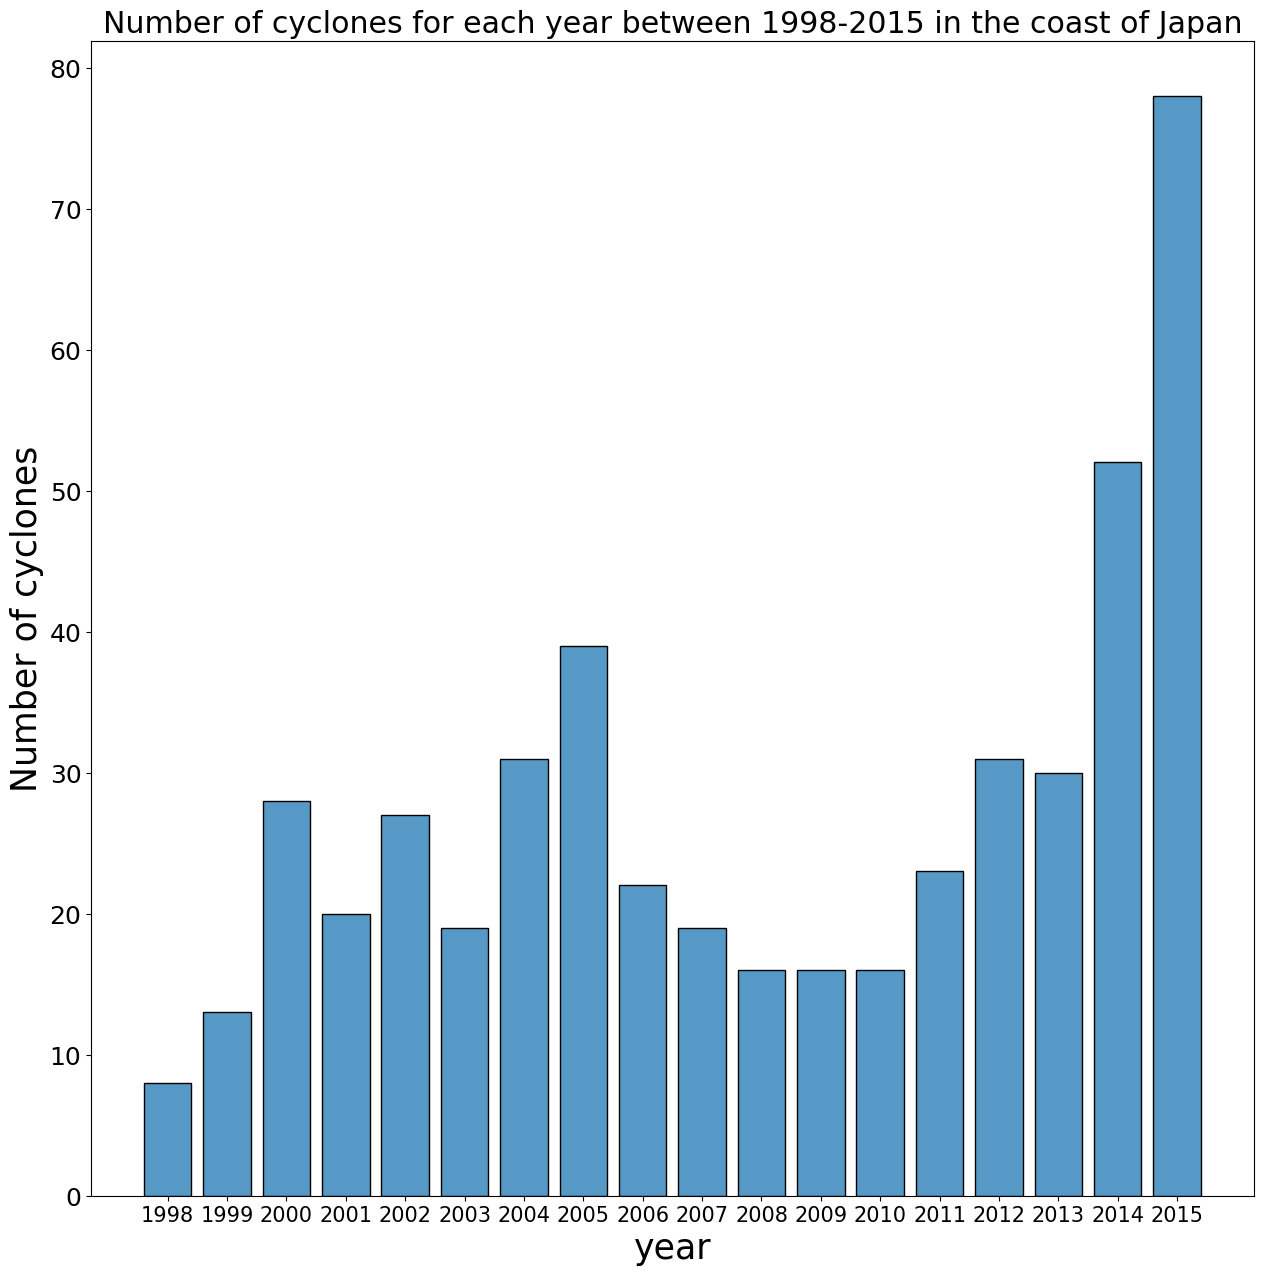

In [ ]:
is_cyclone_day1=is_cyclone_day[(is_cyclone_day['is_cyclone_day']==1)]
is_cyclone_day1=is_cyclone_day1[['day', 'month', 'year', 'is_cyclone_day']]
is_cyclone_day1=is_cyclone_day1.groupby(['year','month', 'day']).mean()


# len(is_cyclone_day1.index.get_level_values('year'))
sns.histplot(is_cyclone_day1.index.get_level_values('month'),shrink=0.8,bins=[i for i in range(1,13)],discrete=True)
ylabel('Number of cyclones')
xlabel('Month')
plt.xticks([i for i in range(1,13)])
title('Number of cyclones for each month between 1998-2015 in the coast of Japan')

figure()
sns.histplot(is_cyclone_day1.index.get_level_values('year'),shrink=0.8,bins=[i for i in range(1998,2016)],discrete=True)
ylabel('Number of cyclones',fontsize=25)
xlabel('year',fontsize=25)
plt.xticks([i for i in range(1998,2016)],fontsize=15)
title('Number of cyclones for each year between 1998-2015 in the coast of Japan')

Also as expected, cyclones appear very frequently during summer (higher SST), and they are very rare in winter.

We also notice that there are more cyclones during certain years (like 2015 for example).

# **III-Cyclone trajectory**

---
Using results from the previous sections, we can now determine the trajectory of a cyclone.


Let's take Hurricane Katrina 2005 as an example

The idea is to visualize the trajectory of Hurricane Katrina over three specific dates—August 29th, 30th, and 31st, 2005—by tracking the movement of cyclonic activity using barycenters.

   



### 1. **Cyclone Activity Per Day:**
   - Each map bellow represents the geographic distribution of cyclonic activity on a particular day.

In [ ]:
%%bigquery is_cyclone_day --project alert-ground-261008
WITH temperature_diff AS (
  SELECT
    lon,
    lat,
    day,
    month,
    year,
    sst,
    CASE
      WHEN LAG(lon) OVER (ORDER BY lon, lat, time) = lon
           AND LAG(lat) OVER (ORDER BY lon, lat, time) = lat THEN
        sst - LAG(sst) OVER (ORDER BY lon, lat, time)
      ELSE
        NULL
    END AS temperature_difference
  FROM
    bdo2020.bdo2020.1998_2015_withtimes
  WHERE
    lon > 260 AND lon < 280
    AND lat > 16 AND lat < 35
  ORDER BY
    lon, lat, time
)
  SELECT
    lon,
    lat,
    day,
    month,
    year,
    temperature_difference,
    CASE
      WHEN temperature_difference <= -2 THEN 1
      ELSE 0
    END AS is_cyclone_day
  FROM
    temperature_diff

Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
def plot_im2(lon,lat,im,size_points,var_name):

    # transform to arrays (just in case)
    lon=array(lon)
    lat=array(lat)
    im=array(im)

    if max(lon)-min(lon)<100:
      # Mercator projection (for small zone)
      m=Basemap(projection='merc',llcrnrlat=nanmin(lat),urcrnrlat=nanmax(lat),\
                llcrnrlon=nanmin(lon),urcrnrlon=nanmax(lon),lat_0=(nanmax(lat)+nanmin(lat))*0.5,\
                lon_0=(nanmax(lon)+nanmin(lon))*0.5,resolution='l')
    else:
      # Orthogonal projection (for large zone)
      m=Basemap(projection='ortho',lat_0=0,lon_0=0,resolution='l')
    # you can use other projections (see https://matplotlib.org/basemap/users/mapsetup.html)

    # transform (lon,lat) to (x,y)
    x,y=m(lon,lat)

    # plot
    im=ma.masked_where(isnan(im),im)
    res=m.scatter(x,y,size_points,im,'o',alpha=1,cmap='Grays',lw=0)
    m.drawcoastlines()
    m.fillcontinents()
    parallels = linspace(nanmin(lat),nanmax(lat),15)
    meridians = linspace(nanmin(lon),nanmax(lon),15)
    #m.drawparallels(parallels,labels=[1,0,0,1],fontsize=10)
    #m.drawmeridians(meridians,labels=[1,0,0,1],fontsize=10)
    cb=m.colorbar(res,location="right")
    cb.set_label(var_name,fontsize=15)

- August, 28th

In [ ]:
is_cyclone_day1=is_cyclone_day[(is_cyclone_day['year']==2005) & (is_cyclone_day['month']==8) & (is_cyclone_day['day']==28)]

Text(0.5, 1.0, 'Number of Tropical cyclones , size=204')

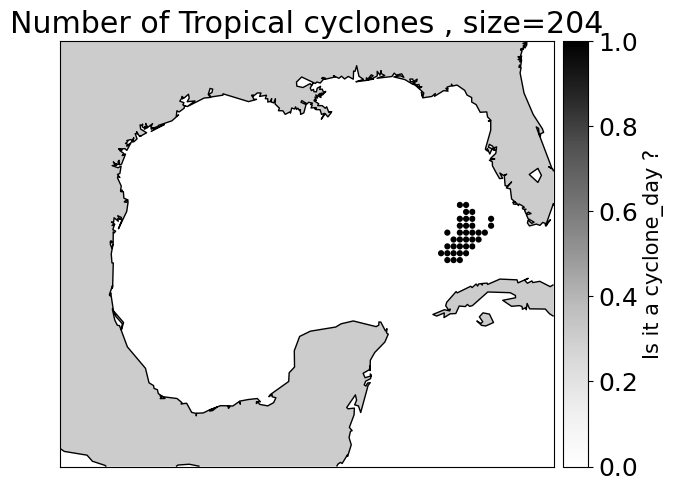

In [ ]:
figure()
subplot(1,2,1)
plot_im2(is_cyclone_day1.lon, is_cyclone_day1.lat, is_cyclone_day1.is_cyclone_day, 20, 'Is it a cyclone_day ?')
title('Number of Tropical cyclones , size=204')

- August, 29th

In [ ]:
is_cyclone_day2=is_cyclone_day[(is_cyclone_day['year']==2005) & (is_cyclone_day['month']==8) & (is_cyclone_day['day']==29)]

Text(0.5, 1.0, 'Number of Tropical cyclones , size=204')

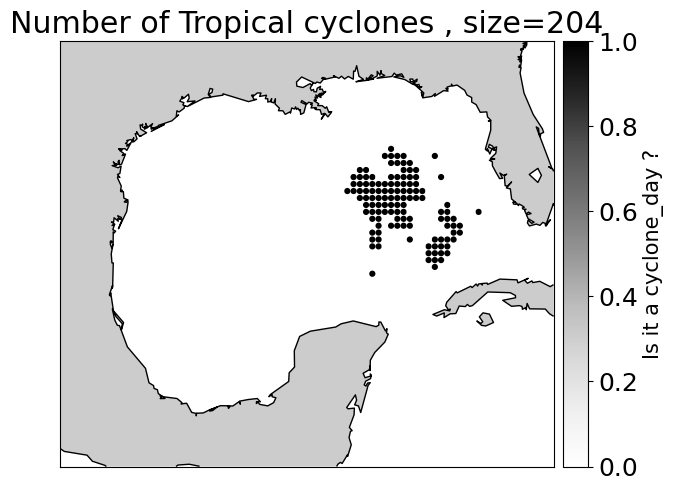

In [ ]:
figure()
subplot(1,2,1)
plot_im2(is_cyclone_day2.lon, is_cyclone_day2.lat, is_cyclone_day2.is_cyclone_day, 20, 'Is it a cyclone_day ?')
title('Number of Tropical cyclones , size=204')

- August, 30th

In [ ]:
is_cyclone_day3=is_cyclone_day[(is_cyclone_day['year']==2005) & (is_cyclone_day['month']==8) & (is_cyclone_day['day']==30)]

Text(0.5, 1.0, 'Number of Tropical cyclones , size=204')

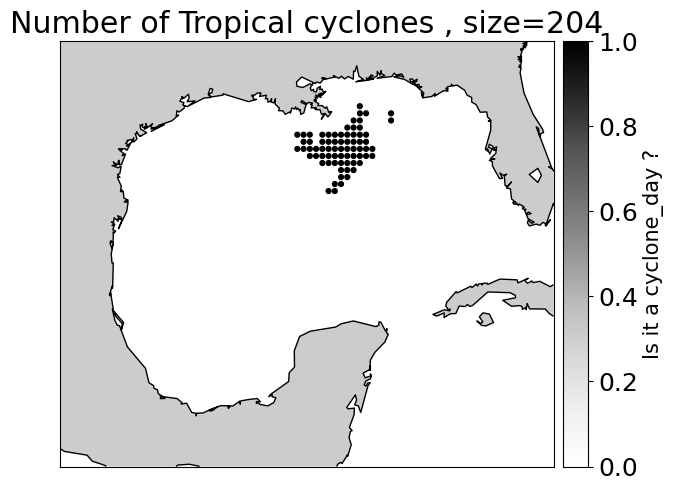

In [ ]:
figure()
subplot(1,2,1)
plot_im2(is_cyclone_day3.lon, is_cyclone_day3.lat, is_cyclone_day3.is_cyclone_day, 20, 'Is it a cyclone_day ?')
title('Number of Tropical cyclones , size=204')

### **2. Barycenters:**
- Barycenters provide a clear **summary of the cyclone's central position** for each day, calculated as the average latitude and longitude of cyclonic activity. This simplifies the complex spatial distribution of storm activity into a single representative point.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Filtrer les pixels où il y a un cyclone
cyclone_data = is_cyclone_day[
    (is_cyclone_day["is_cyclone_day"] == 1) &
    (is_cyclone_day["year"] == 2005) ]



# Calculer le barycentre (moyenne des longitudes et latitudes) par jour
barycenters = (
    cyclone_data.groupby(["year", "month", "day"])
    .agg(
        lon_mean=("lon", "mean"),
        lat_mean=("lat", "mean"),
    )
    .reset_index()
)

### **3. Trajectory and Day Progression:**
   - This map combines the information to illustrate the **overall movement of Hurricane Katrina over these three days**.
   - **Colored dots** indicate the barycenter of cyclonic activity for each day:
     - **Red** (August 29th): Indicates the starting position of Hurricane Katrina.
     - **Orange** (August 30th): Shows the intermediate location as the storm progresses.
     - **Yellow** (August 31st): Marks the position of the cyclone on the final day of observation.
   - The gradient from red to yellow highlights **temporal progression** and allows us to visually trace the storm's path.

### **4. Applications**

#### **- Hurricanes at the gulf of Mexico in 2005**




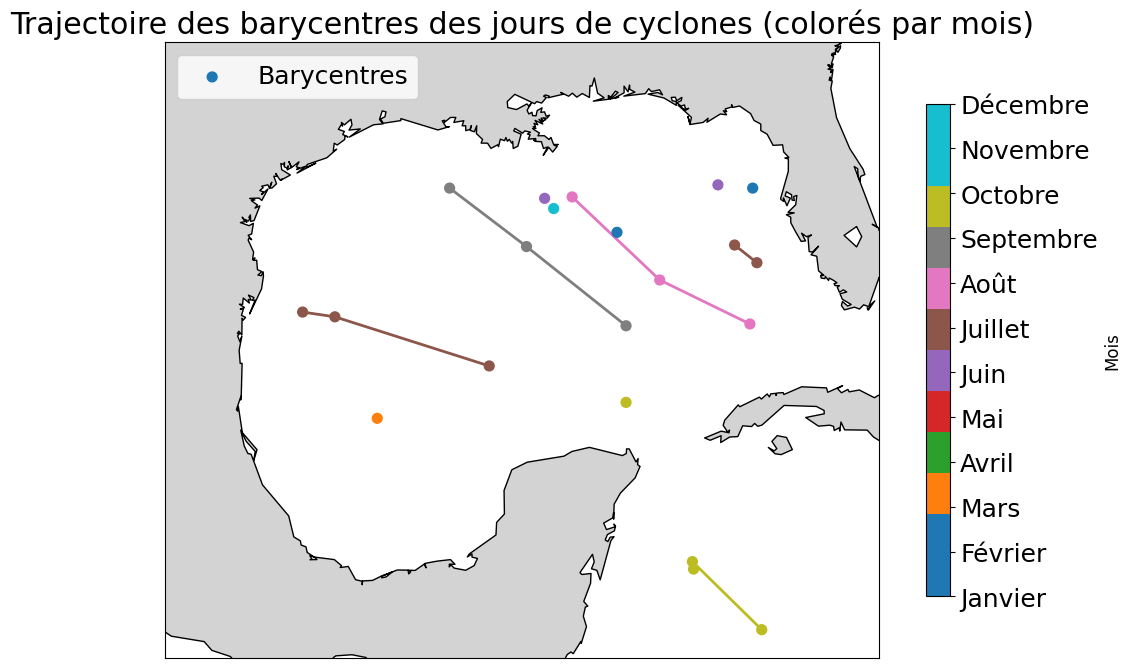

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import matplotlib.colors as mcolors

# Tracer les barycentres avec une colorbar basée sur les mois
def plot_cyclone_path_with_months(barycenters):
    # Initialisation de la carte
    m = Basemap(projection='merc', llcrnrlat=16.125, urcrnrlat=31.625,
                llcrnrlon=260.125, urcrnrlon=279.875, resolution='l')
    plt.figure(figsize=(12, 8))

    # Ajouter les côtes et continents
    m.drawcoastlines()
    m.fillcontinents(color='lightgray', zorder=0)

    # Transformation des coordonnées pour la carte
    barycenters['x'], barycenters['y'] = m(
        barycenters['lon_mean'].values,
        barycenters['lat_mean'].values
    )

    # Définir une colormap pour les mois (de 1 à 12)
    cmap = plt.cm.get_cmap('tab10', 12)  # 12 couleurs pour les 12 mois
    norm = mcolors.Normalize(vmin=1, vmax=12)

    # Tracer les barycentres avec des couleurs selon les mois
    scatter = m.scatter(
        barycenters['x'], barycenters['y'],
        c=barycenters['month'],
        cmap=cmap, norm=norm,
        s=50, label='Barycentres', zorder=2
    )

    # Tracer des lignes entre jours consécutifs
    for i in range(len(barycenters) - 1):
        day1 = barycenters.iloc[i]
        day2 = barycenters.iloc[i + 1]

        # Vérifier si les jours sont consécutifs
        if (day2['year'] == day1['year'] and
            day2['month'] == day1['month'] and
            day2['day'] == day1['day'] + 1):

            plt.plot(
                [day1['x'], day2['x']],
                [day1['y'], day2['y']],
                color=cmap(norm(day1['month'])),  # Utiliser la couleur du mois
                linestyle='-', linewidth=2, zorder=1
            )

    # Ajouter une colorbar
    cbar = plt.colorbar(scatter, orientation='vertical', shrink=0.8)
    cbar.set_label('Mois', fontsize=12)
    cbar.set_ticks(range(1, 13))
    cbar.set_ticklabels([
        'Janvier', 'Février', 'Mars', 'Avril', 'Mai', 'Juin',
        'Juillet', 'Août', 'Septembre', 'Octobre', 'Novembre', 'Décembre'
    ])

    # Ajouter une légende et un titre
    plt.legend()
    plt.title('Trajectoire des barycentres des jours de cyclones (colorés par mois)')
    plt.show()

# Appel de la fonction avec les barycentres calculés
plot_cyclone_path_with_months(barycenters)


By comparing our results to the map below, extracted from the Historical Hurricane Tracks, the outcome appears to be highly coherent. (Summer 2005)
![Hurricanes in the guld of Mexica in summer 2005.](https://drive.google.com/uc?id=1zRi49EbD9QAC7IefG3PB85GO_cgkPY_D)

We were able to identify four hurricanes trajectory:
- 1 = brown (in our result map)  Emily Hurricane
- 2 = pink (in our result map) Katrina Hurricane
- 3 = gray (in our result map) Rita Hurricane
- 4 = yellow (in our result map) Wilma Hurricane

#### **- Hurricanes at the coast of Japan in summer 2015**

In [ ]:
%%bigquery is_cyclone_day --project alert-ground-261008
WITH temperature_diff AS (
  SELECT
    lon,
    lat,
    day,
    month,
    year,
    sst,
    CASE
      WHEN LAG(lon) OVER (ORDER BY lon, lat, time) = lon
           AND LAG(lat) OVER (ORDER BY lon, lat, time) = lat THEN
        sst - LAG(sst) OVER (ORDER BY lon, lat, time)
      ELSE
        NULL
    END AS temperature_difference
  FROM
    bdo2020.bdo2020.1998_2015_withtimes
  WHERE
    lon > 120 AND lon < 140
    AND lat > 20 AND lat < 40
)
SELECT
  lon,
  lat,
  day,
  month,
  year,
  temperature_difference,
  CASE
    WHEN temperature_difference <= -2 THEN 1
    ELSE 0
  END AS is_cyclone_day
FROM
  temperature_diff

Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Filtrer les pixels où il y a un cyclone
cyclone_data = is_cyclone_day[
    (is_cyclone_day["is_cyclone_day"] == 1) &
    (is_cyclone_day["year"] == 2015) ]



# Calculer le barycentre (moyenne des longitudes et latitudes) par jour
barycenters = (
    cyclone_data.groupby(["year", "month", "day"])
    .agg(
        lon_mean=("lon", "mean"),
        lat_mean=("lat", "mean"),
    )
    .reset_index()
)

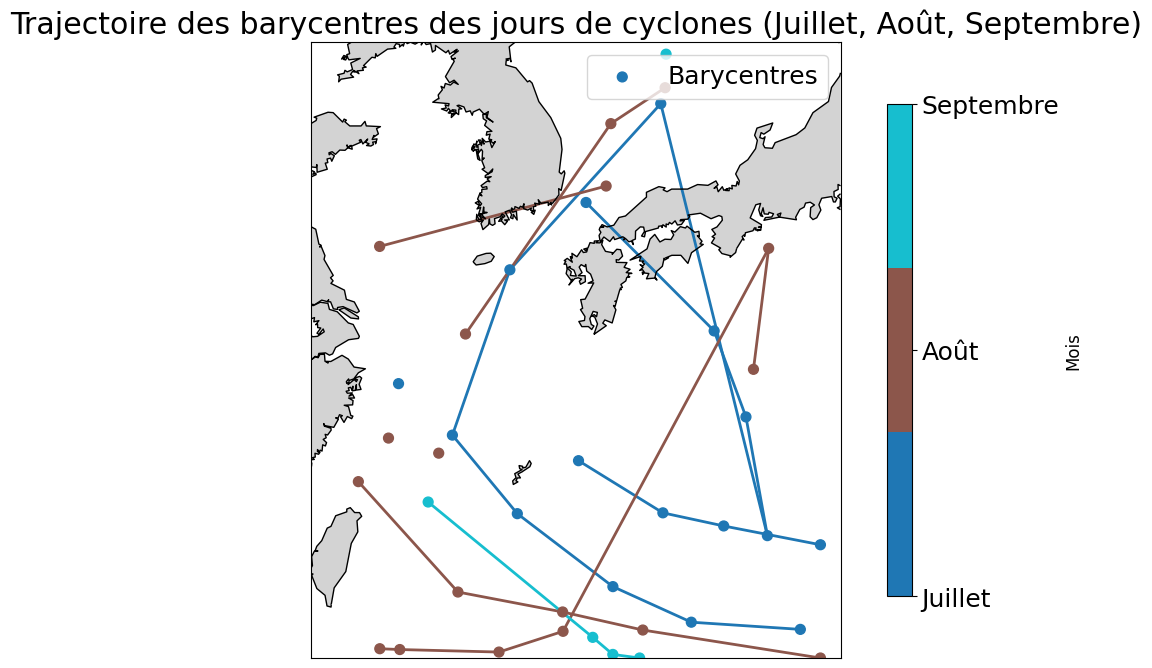

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import matplotlib.colors as mcolors

# Tracer les barycentres avec une colorbar basée sur les mois
def plot_cyclone_path_with_months(barycenters):
    # Filtrer pour ne garder que les mois de Juillet (7), Août (8), et Septembre (9)
    barycenters = barycenters[barycenters['month'].isin([7, 8, 9])]

    # Initialisation de la carte
    m = Basemap(projection='merc', llcrnrlat=20.125, urcrnrlat=39.875,
                llcrnrlon=120.125, urcrnrlon=139.875, resolution='l')
    plt.figure(figsize=(12, 8))

    # Ajouter les côtes et continents
    m.drawcoastlines()
    m.fillcontinents(color='lightgray', zorder=0)

    # Transformation des coordonnées pour la carte
    barycenters['x'], barycenters['y'] = m(
        barycenters['lon_mean'].values,
        barycenters['lat_mean'].values
    )

    # Définir une colormap pour les mois (uniquement pour 7, 8, 9)
    cmap = plt.cm.get_cmap('tab10', 3)  # 3 couleurs pour Juillet, Août, Septembre
    norm = mcolors.Normalize(vmin=7, vmax=9)

    # Tracer les barycentres avec des couleurs selon les mois
    scatter = m.scatter(
        barycenters['x'], barycenters['y'],
        c=barycenters['month'],
        cmap=cmap, norm=norm,
        s=50, label='Barycentres', zorder=2
    )

    # Tracer des lignes entre jours consécutifs
    for i in range(len(barycenters) - 1):
        day1 = barycenters.iloc[i]
        day2 = barycenters.iloc[i + 1]

        # Vérifier si les jours sont consécutifs
        if (day2['year'] == day1['year'] and
            day2['month'] == day1['month'] and
            day2['day'] == day1['day'] + 1):

            plt.plot(
                [day1['x'], day2['x']],
                [day1['y'], day2['y']],
                color=cmap(norm(day1['month'])),  # Utiliser la couleur du mois
                linestyle='-', linewidth=2, zorder=1
            )

    # Ajouter une colorbar
    cbar = plt.colorbar(scatter, orientation='vertical', shrink=0.8)
    cbar.set_label('Mois', fontsize=12)
    cbar.set_ticks([7, 8, 9])
    cbar.set_ticklabels(['Juillet', 'Août', 'Septembre'])

    # Ajouter une légende et un titre
    plt.legend()
    plt.title('Trajectoire des barycentres des jours de cyclones (Juillet, Août, Septembre)')
    plt.show()

# Appel de la fonction avec les barycentres calculés
plot_cyclone_path_with_months(barycenters)

By comparing our results to the map below, extracted from the Historical Hurricane Tracks, the outcome appears to be highly coherent. (Summer 2015)
![Hurricanes in the coast of Japan in summer 2005.](https://drive.google.com/uc?id=1U7iHdOBRHSClxmsyQRuiw9JrTAnLiOBo)

We were able to identify 3 hurricanes trajectory (approximately):
- sky blue that matches with soude l'or Hurricane
- brown that matches with Goni Hurricane
- blue that matches with Chan-HOM Hurricane